In [3]:
import xarray as xr
import pandas as pd
import rioxarray
import numpy as np
import dask
import dask.array as da
from dask.distributed import Client, LocalCluster, wait
from pathlib import Path
import zarr
import json
import joblib
from sklearn.metrics import mean_squared_error, r2_score
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import FuncFormatter
import geopandas as gpd

from scipy.stats import pearsonr, spearmanr

root = Path.cwd()

def predict_block(block,clf,rgr):

    n_band, bh, bw = block.shape
    pixels = block.reshape(n_band,-1).T # (pixels, bands)

    valid = np.all(np.isfinite(pixels),axis=1)
    #tc_binary = np.full(bh * bw, np.nan)
    tc_percent = np.full(bh * bw, np.nan)

    if valid.any():
        clf_preds = clf.predict(pixels[valid])
        #clf_preds = (clf_probs >= clf_thresh).astype(int)
        #tc_binary[valid] = clf_preds

        tc_percent[valid] = 0  ## set to zero not nan

        canopy_mask = valid.copy()
        canopy_mask[valid] = (clf_preds == 1)

        if canopy_mask.any():
            tc_percent[canopy_mask] = rgr.predict(pixels[canopy_mask])
    
    return tc_percent.reshape(bh,bw)

def predict_block_oof(chunk, fold_chunk, models):
    out = np.full(chunk.shape[1:], np.nan, dtype=np.float32)
    for f in np.unique(fold_chunk):
        if f == 7 :
            continue                # excluded pixels
        else:
            clf, rgr = models[int(f)]           # select the model that held this fold out of training
        m = (fold_chunk == f)
        if not m.any():
            continue
        # predict only this fold's pixels within the chunk
        sub = np.where(m[None, :, :], chunk, np.nan)
        pred = predict_block(sub, clf, rgr)      # same function as non-oof preds
        out[m] = pred[m]
    return out

import io

def get_model_size_mb(model):
    buf = io.BytesIO()
    joblib.dump(model, buf)
    return buf.tell() / 1e6

#### Sequential Rasterio version

In [7]:
siteyear='nyc18'
input_data = xr.open_zarr(root / 'data' / siteyear / f'{siteyear}_seasonalstats.zarr')['features']

medians_only = [c for c in input_data.band.values if not any(t in str(c) for t in ['contrast', 'dissimilarity', 'homogeneity','ASM', 'variance','entropy']) and 'median' in c]

In [9]:
gs_medians_only = [c for c in medians_only if 'season' in c]

In [11]:
import rasterio
import numpy as np

def predict_citywide_tree_canopy(siteyear):

    if siteyear == 'nyc21':
        oof = True
    else:
        oof = False

    input_data = xr.open_zarr(root / 'data' / siteyear / f'{siteyear}_seasonalstats.zarr')['features']

    medians_only_a = [c for c in input_data.band.values if not any(t in str(c) for t in ['contrast', 'dissimilarity', 'homogeneity','ASM', 'variance','entropy']) and 'median' in c]
    medians_only = [c for c in medians_only_a if 'season' in c]

    input_data = input_data.sel(band=medians_only)
    input_data = input_data.rio.write_crs(26918).rio.set_spatial_dims( x_dim="x",y_dim="y").rio.write_coordinate_system()

    height, width = input_data.shape[1], input_data.shape[2]
    transform = input_data.rio.transform()
    crs = input_data.rio.crs
    chunk_y = 256
    chunk_x = 256

    if not oof:
        # clf = joblib.load(root / 'models' / 'nyc21' / f'nyc21_medians_only_fulldata_clf.joblib')['clf_model']
        # rgr = joblib.load(root / 'models' / 'nyc21' / f'nyc21_medians_only_fulldata_rgr.joblib')['rgr_model']
        clf = joblib.load(root / 'models' / 'nyc21' / f'nyc21_median_season_only_clf.joblib')['clf_model']
        rgr = joblib.load(root / 'models' / 'nyc21' / f'nyc21_median_season_only_rgr.joblib')['rgr_model']
    else:
        oof_items = joblib.load(root / 'models' / 'nyc21' / 'nyc21_medians_only_OOF_models.joblib')
        oof_models = oof_items['models']
        fold_raster = xr.DataArray(oof_items['fold_array'],dims=['y','x'],coords={'y':input_data.y,'x':input_data.x})

    with rasterio.open(
        root/'model_outputs'/f'{siteyear}_from_nyc21_median_season_only_model_canopy_percent.tif',
        'w', driver='GTiff', height=height, width=width,
        count=1, dtype=np.float32, crs=crs,
        transform=transform, compress='lzw'
    ) as dst:
        for y_start in range(0, height, chunk_y):
            for x_start in range(0, width, chunk_x):
                y_end = min(y_start + chunk_y, height)
                x_end = min(x_start + chunk_x, width)

                chunk = input_data.isel(
                    y=slice(y_start, y_end),
                    x=slice(x_start, x_end)
                ).compute().values

                if not oof:
                    result = predict_block(
                        chunk, clf=clf,rgr=rgr
                    )
                else:
                    fold_chunk = fold_raster.isel(y=slice(y_start, y_end), x=slice(x_start, x_end)).values
                    result = predict_block_oof(chunk, fold_chunk, oof_models)

                window = rasterio.windows.Window(
                    x_start, y_start,
                    x_end - x_start, y_end - y_start
                )
                dst.write(result.astype(np.float32), 1, window=window)
                
    print("Done")

In [9]:
import joblib

input_data = xr.open_zarr(root / 'data' / 'nyc21' / f'nyc21_seasonalstats.zarr')['features']
oof_items = joblib.load(root / 'models' / 'nyc21' / f'nyc21_medians_only_models.joblib')
#oof_models = oof_items['models']
#fold_raster = xr.DataArray(oof_items['fold_array'],dims=['y','x'],coords={'y':input_data.y,'x':input_data.x})
features = oof_items['input_features']

In [15]:
band_names = [f"band_{b}" for b in input_data.coords["band"].values]

In [18]:
band_names 

['band_B02_season_median',
 'band_B03_season_median',
 'band_B04_season_median',
 'band_B05_season_median',
 'band_B06_season_median',
 'band_B07_season_median',
 'band_B08_season_median',
 'band_B8A_season_median',
 'band_B11_season_median',
 'band_B12_season_median',
 'band_s2w_season_median',
 'band_ndm_season_median',
 'band_ndr_season_median',
 'band_grv_season_median',
 'band_psr_season_median',
 'band_tdv_season_median',
 'band_nbr_season_median',
 'band_bsi_season_median',
 'band_B02_season_iqr',
 'band_B03_season_iqr',
 'band_B04_season_iqr',
 'band_B05_season_iqr',
 'band_B06_season_iqr',
 'band_B07_season_iqr',
 'band_B08_season_iqr',
 'band_B8A_season_iqr',
 'band_B11_season_iqr',
 'band_B12_season_iqr',
 'band_s2w_season_iqr',
 'band_ndm_season_iqr',
 'band_ndr_season_iqr',
 'band_grv_season_iqr',
 'band_psr_season_iqr',
 'band_tdv_season_iqr',
 'band_nbr_season_iqr',
 'band_bsi_season_iqr',
 'band_B02_spring_median',
 'band_B03_spring_median',
 'band_B04_spring_median',
 

In [ ]:
predict_citywide_tree_canopy('nyc18')


### Results Analysis

#### Resample and compare to lidar

In [ ]:



def resample_predictions(pred_raster,lidar_raster,scales):
    assert pred_raster.shape == lidar_raster.shape

    ## make shared valid mask
    valid= lidar_raster.notnull() & pred_raster.notnull()
    pred_valid = pred_raster.where(valid)
    lidar_valid = lidar_raster.where(valid)

    rows = []
    resampled_preds = {}
    resampled_lidar = {}
    coverage_dict = {}
     
    for i in scales:
        assert i % 10 == 0 , f'scale {i} not a factor of 10'
        factor = int(i // 10) # 500m / 10m

        lidar_sum = lidar_valid.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()
        canopy_sum = pred_valid.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()
        land_count = valid.astype('float32').rio.write_nodata(None).coarsen(x=factor, y=factor, boundary='pad').sum()

        min_land = 0.2 * factor**2 ## valid pixels must be >= 20% of coarser pixel area
      
        coverage_mask = land_count >= min_land
       
        pred_c = (canopy_sum / land_count).where(coverage_mask) # same mask applied to both preds and lidar
        lidar_c = (lidar_sum / land_count).where(coverage_mask)
      
        resampled_preds[f'preds_{i}'] = pred_c
        resampled_lidar[f'lidar_{i}'] = lidar_c
        coverage_dict[f'coverage_{i}'] = land_count

        m = coverage_mask
        
        p = pred_c.where(m).values.ravel()
        l = lidar_c.where(m).values.ravel()
        finite = np.isfinite(p) & np.isfinite(l)

        rows.append({'res': i,
                     'rmse': round(np.sqrt(mean_squared_error(l[finite], p[finite])), 2),
                     'r2':   round(r2_score(l[finite], p[finite]), 2),
                     'n_cells': int(finite.sum())})

    return pd.DataFrame(rows), resampled_preds, resampled_lidar, coverage_dict

def resample_predictions_no_lidar(pred_raster,scales):
   
    valid = pred_raster.notnull()
    pred_valid = pred_raster.where(valid)
    
    resampled_preds = {}
    coverage_dict = {}
   
    for i in scales:
        assert i % 10 == 0 , f'scale {i} not a factor of 10'
        factor = int(i // 10) # 500m / 10m
        canopy_sum = pred_valid.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()
        land_count = valid.astype('float32').rio.write_nodata(None).coarsen(x=factor, y=factor, boundary='pad').sum()

        min_land = 0.2 * factor**2 ## valid pixels must be >= 20% of coarser pixel area
        coverage_mask = land_count >= min_land
        pred_c = (canopy_sum / land_count).where(coverage_mask)
        
      
        resampled_preds[f'preds_{i}'] = pred_c
        coverage_dict[f'coverage_{i}'] = land_count
   
    return resampled_preds, coverage_dict

In [2]:
def resample_coverage(pred_raster,scales):
   
    valid = pred_raster.notnull()
   
    coverage_dict = {}
   
    for i in scales:
        assert i % 10 == 0 , f'scale {i} not a factor of 10'
        factor = int(i // 10) # 500m / 10m

        land_count = valid.astype('float32').rio.write_nodata(None).coarsen(x=factor, y=factor, boundary='pad').sum()
        coverage = valid.astype('float32').rio.write_nodata(None).coarsen(x=factor, y=factor, boundary='pad').mean()

        min_land = 0.2 * factor**2 ## valid pixels must be >= 20% of coarser pixel area
        coverage_mask = land_count >= min_land
        coverage_out = (coverage).where(coverage_mask)
 
        coverage_dict[f'coverage_{i}'] = coverage_out
   
    return coverage_dict

In [ ]:
import os
os.makedirs(root / 'model_outputs' / 'resampled',exist_ok=True)

years = [18,19,20,21]
scales = [30,100,500,1000,2000]
save_dir = root / 'model_outputs' / 'resampled'
for y in years:
    p = rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{y}_from_nyc21_medians_only_model_canopy_percent.tif')
    if y in [18,21]:

        l = rioxarray.open_rasterio(root / 'data' / f'nyc{y}' / f'nyc{y}_tree_canopy_lidar.tif')
        df, preds_resamp, lidar_resamp, coverage_resamp = resample_predictions(pred_raster=p,lidar_raster=l,scales=scales)
        df.to_csv(save_dir/f'resamp_20{y}.csv')
        for k,v in preds_resamp.items():
            v.rio.to_raster(save_dir / f'resamp_{k}_20{y}.tif')
        for k,v in lidar_resamp.items():
            v.rio.to_raster(save_dir / f'resamp_{k}_20{y}.tif')
        for k,v in coverage_resamp.items():
            v.rio.to_raster(save_dir / f'resamp_{k}_20{y}_coverage.tif')

    else:
        preds_resamp, coverage_resamp = resample_predictions_no_lidar(pred_raster=p,scales=scales)
        for k,v in preds_resamp.items():
            v.rio.to_raster(save_dir / f'resamp_{k}_20{y}.tif')
        for k,v in coverage_resamp.items():
            v.rio.to_raster(save_dir / f'resamp_{k}_20{y}_coverage.tif')

In [4]:
years = [18,21]
scales = [30,100,500,1000,2000]
save_dir = root / 'model_outputs' / 'resampled'
for y in years:
    p = rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{y}_from_nyc21_medians_only_model_canopy_percent.tif')
    coverage_resamp = resample_coverage(pred_raster=p,scales=scales)
    for k,v in coverage_resamp.items():
        v.rio.to_raster(save_dir / f'resamp_{k}_20{y}_coverage.tif')


#### Aggregate to Political Boundaries

In [36]:
from exactextract import exact_extract 
import geopandas as gpd
import pandas as pd
import xarray
import rioxarray
from pathlib import Path
root = Path.cwd()
def boundary_stats(boundary,year):

    p1 = rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{year}_from_nyc21_medians_only_model_canopy_percent.tif')
    l1 = rioxarray.open_rasterio(root / 'data' / f'nyc{year}' / f'nyc{year}_tree_canopy_lidar.tif')


    ## make shared valid mask
    valid= p1.notnull() & l1.notnull() 
    p1_valid = p1.where(valid)
    l1_valid = l1.where(valid)
    b = boundary.drop(columns=['boro_code','shape_area','shape_leng'])

    bb = b.union_all()

    bb_gdf = gpd.GeoDataFrame({'boro_name':'Full City'},geometry=[bb],index=[0],crs=b.crs)

    bounds = pd.concat([b,bb_gdf])

    pred_stats = exact_extract(p1_valid,bounds,'mean(min_coverage_frac=0.5)',include_cols=['boro_name'],output='pandas')
    pred_stats = pred_stats.rename(columns={'mean':'pred_mean'})
    lidar_stats = exact_extract(l1_valid,bounds,'mean(min_coverage_frac=0.5)',include_cols=['boro_name'],output='pandas')
    lidar_stats = lidar_stats.rename(columns={'mean':'lidar_mean'})
    out = pred_stats.merge(lidar_stats,on='boro_name')

    return out

In [ ]:
boundary = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
bstats_2018 = boundary_stats(boundary=boundary,year=18)
bstats_2021 = boundary_stats(boundary=boundary,year=21)

lidar_diff = bstats_2021['lidar_mean'] - bstats_2018['lidar_mean']
pred_diff = bstats_2021['pred_mean'] - bstats_2018['pred_mean']
bstats_diffs = pd.DataFrame({'boro_name':bstats_2018['boro_name'],'pred_diff':pred_diff,'lidar_diff':lidar_diff})

In [76]:
lidar_diff - pred_diff

0    1.817882
1   -1.332855
2    0.629518
3    0.188675
4    0.330575
5    0.237600
dtype: float64

In [75]:
print(f'2018 mean resid: {(bstats_2018['pred_mean'] - bstats_2018['lidar_mean']).mean()}')
print(f'2021 mean resid: {(bstats_2021['pred_mean'] - bstats_2021['lidar_mean']).mean()}')

2018 mean resid: -1.1273052639368693
2021 mean resid: -1.439204391631011


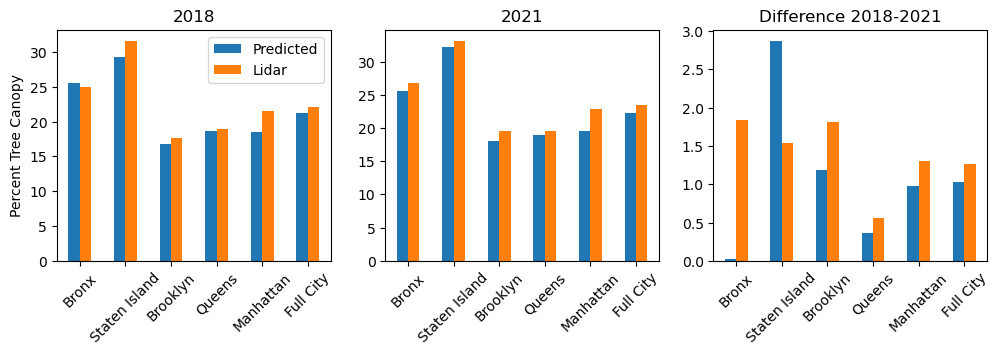

In [54]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3,figsize=(12,3))

bstats_2018.plot.bar(ax=axes[0],x='boro_name',rot=45)
axes[0].set_title('2018')
axes[0].legend(labels=['Predicted','Lidar'])
axes[0].set_ylabel('Percent Tree Canopy')

bstats_2021.plot.bar(ax=axes[1],x='boro_name',legend=False,rot=45)
axes[1].set_title('2021')

bstats_diffs.plot.bar(ax=axes[2],x='boro_name',legend=False,rot=45)
axes[2].set_title('Difference 2018-2021')

for ax in axes:
    ax.set_xlabel(None)

plt.show()




In [15]:
bstats_2021

,boro_name,mean,source
0,Bronx,25.608975,predicted
1,Staten Island,32.150135,predicted
2,Brooklyn,17.990134,predicted
3,Queens,18.953793,predicted
4,Manhattan,19.518692,predicted
5,city,22.245213,predicted
0,Bronx,26.747278,lidar
1,Staten Island,33.129005,lidar
2,Brooklyn,19.487986,lidar
3,Queens,19.534190,lidar


##### Change through time

In [ ]:
## need to ensure aggregations had the same denominator for all four years
## otherwise change could be due to different number of valid pixels, not change in tree canopy

## create common validity mask and apply before aggregating


## keep existing resamp tifs for individual year comparison with lidar

In [4]:
def apply_valid_mask(p,l,v):
    p_valid = p.where(v)
    l_valid = l.where(v)
    return p_valid, l_valid

def resample_valid_only(p,l,land_count,coverage_mask,factor):
    l_sum = l.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()
    p_sum = p.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()

    pred_c = (p_sum / land_count).where(coverage_mask) # same mask applied to both preds and lidar
    lidar_c = (l_sum / land_count).where(coverage_mask)

    return pred_c, lidar_c

def resample_and_diff_predictions(scales,years=[18,21]):
    p1 = rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{years[0]}_from_nyc21_medians_only_model_canopy_percent.tif')
    l1 = rioxarray.open_rasterio(root / 'data' / f'nyc{years[0]}' / f'nyc{years[0]}_tree_canopy_lidar.tif')

    p2 = rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{years[1]}_from_nyc21_medians_only_model_canopy_percent.tif')
    l2 = rioxarray.open_rasterio(root / 'data' / f'nyc{years[1]}' / f'nyc{years[1]}_tree_canopy_lidar.tif')
    assert p1.shape == p2.shape

    ## make shared valid mask
    valid= p1.notnull() & p2.notnull() & l1.notnull() & l2.notnull()
    p1_valid, l1_valid = apply_valid_mask(p1,l1,valid)
    p2_valid, l2_valid = apply_valid_mask(p2,l2,valid)
     
    for i in scales:
        assert i % 10 == 0 , f'scale {i} not a factor of 10'
        factor = int(i // 10) 

        land_count = valid.astype('float32').rio.write_nodata(None).coarsen(x=factor, y=factor, boundary='pad').sum()
        min_land = 0.2 * factor**2 ## valid pixels must be >= 20% of coarser pixel area
      
        coverage_mask = land_count >= min_land
        ## all caclulations have the same denominator (land count)
        p1_c, l1_c = resample_valid_only(p=p1_valid,l=l1_valid,land_count=land_count,coverage_mask=coverage_mask,factor=factor)
        p2_c, l2_c = resample_valid_only(p=p2_valid,l=l2_valid,land_count=land_count,coverage_mask=coverage_mask,factor=factor)

        p_diff = p2_c - p1_c
        l_diff = l2_c - l1_c

        p_diff.rio.to_raster(save_dir/ f'diff_preds_20{years[0]}_20{years[1]}_{i}m.tif')
        l_diff.rio.to_raster(save_dir/ f'diff_lidar_20{years[0]}_20{years[1]}_{i}m.tif')
        land_count.rio.to_raster(save_dir / f'diff_coverage_20{years[0]}_20{years[1]}_{i}m.tif')
      


In [5]:
scales = [30,100,500,1000,2000]
save_dir = root / 'model_outputs' / 'resampled'

resample_and_diff_predictions(scales=scales)

In [ ]:
def resample_and_fit_predictions(scales,years):
    r = xr.concat([rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{year}_from_nyc21_medians_only_model_canopy_percent.tif').squeeze('band') for year in years],dim=pd.Index([2018,2019,2020,2021],name='year'))

    l = xr.concat([rioxarray.open_rasterio(root / 'data' / f'nyc{year}' / f'nyc{year}_tree_canopy_lidar.tif').squeeze('band') for year in [18,21]],dim=pd.Index([2018,2021],name='year'))

    assert r.rio.transform() == l.rio.transform()
    # common validity mask
    valid = r.notnull().all('year') & l.notnull().all('year')

    r_valid = r.where(valid)
    l_valid = l.where(valid)

    for i in scales:
        assert i % 10 == 0 , f'scale {i} not a factor of 10'
        factor = int(i // 10) 

        land_count = valid.astype('float32').rio.write_nodata(None).coarsen(x=factor, y=factor, boundary='pad').sum()
        min_land = 0.2 * factor**2 ## valid pixels must be >= 20% of coarser pixel area
        
        coverage_mask = land_count >= min_land
        ## all caclulations have the same denominator (land count)
    
        p_sum = r_valid.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()
        pred_c = (p_sum / land_count).where(coverage_mask)
        
        fit = pred_c.polyfit(dim='year', deg=1,full=True)
        slope = fit.polyfit_coefficients.sel(degree=1)
        rmse_fit = np.sqrt(fit.polyfit_residuals / (r.year.size - 2)) 

        slope = slope.rio.write_crs(r.rio.crs)
        slope.rio.to_raster(save_dir / f'slope_preds_2018_2021_{i}m.tif')

        rmse_fit = rmse_fit.rio.write_crs(r.rio.crs)
        rmse_fit.rio.to_raster(save_dir / f'rmse_slope_preds_2018_2021_{i}m.tif')

        # match lidar
        l_sum = l_valid.fillna(0).coarsen(x=factor, y=factor, boundary='pad').sum()
        l_c = (l_sum / land_count).where(coverage_mask)
        l_diff = (l_c.sel(year=2021) - l_c.sel(year=2018)) / 3  ## divide by 3 to put on same scale as slope
        l_diff.rio.to_raster(save_dir / f'slope_lidar_2018_2021_{i}m.tif')
    

In [38]:
save_dir = root / 'model_outputs' / 'resampled'
scales = [10]
years = [18,19,20,21]
resample_and_fit_predictions(scales=scales,years=years)

In [ ]:
# this approach is janky because setting thresholds for both lidar and predictions is arbitrary

# evaluate change
# get stable pixels from lidar
# get range of predicted change for these pixels = this is noise window

## convert change rasters to categories: stable, gain and loss
# make confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

def classify_change(r,threshold):
    out = np.full(r.shape,np.nan,np.float32) 
    out[(r> -threshold)&(r<threshold)] = 1.0
    out[r > threshold] = 2.0 # gain
    out[r < -threshold] = 0.0 # loss
    return out

# scales = [30,100,500,1000,2000]
i = 30
p = rioxarray.open_rasterio(save_dir/ f'diff_preds_2018_2021_{i}m.tif').squeeze('band')
l = rioxarray.open_rasterio(save_dir/ f'diff_lidar_2018_2021_{i}m.tif').squeeze('band')
v = np.isfinite(p) & np.isfinite(l)
# pixels where lidar shows stability 
## what would be considered 'stable' at each scale?
lidar_std = np.std(l.values[v])
lidar_thresh = lidar_std *0.1#based on what would be of management concern at each scale, or based on distribution.
stable = np.abs(l.values)<lidar_thresh
pred_noise = p.values[stable & np.isfinite(p.values)]

bias = np.nanmean(pred_noise)
sigma = np.std(pred_noise)
#threshold = sigma * 1.96 ## this assumes a mean of 0
lo, hi = np.percentile(pred_noise,[1.0,99.0]) ## instead of setting thresholds, keep continuous

def classify_change(r,lo,hi):
    out = np.full(r.shape,np.nan,np.float32) 
    out[(r> lo)&(r<hi)] = 1.0 ## pixels within threshold coded as 'stable'
    out[r > hi] = 2.0 # gain
    out[r < lo] = 0.0 # loss
    return out

p_cat = classify_change(p,lo=lo,hi=hi) # use threshold for predictions
l_cat = classify_change(l,lo=-lidar_thresh,hi=lidar_thresh) # use 1.0 for lidar


p_cat_2d = p_cat[v].ravel()
l_cat_2d = l_cat[v].ravel()

ConfusionMatrixDisplay.from_predictions(
   l_cat_2d, p_cat_2d,normalize='true')


In [ ]:
def robust_std(x):
    ## median absolute deviation from the median (more robust than standard deviation)
    if x.size == 0:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad ## constant scale factor for normal distribution

def _nash_sutcliffe(obs, sim):   # obs = lidar, sim = preds
    ## recommended metric of model accuracy by Wadoux (2024)
    # also called Modeling Efficiency Coefficient (MEC)
    if obs.size < 2:
        return np.nan
    denom = np.sum((obs - obs.mean()) ** 2)  # lidar variance
    if denom == 0:
        return np.nan
    return 1.0 - np.sum((obs - sim) ** 2) / denom ## error variance / lidar variance

def _concordance_cc(x, y): # l, p
    ##Lin's concordance correlation coefficient. Wadoux (2024) throws shade.
    if x.size < 2:
        return np.nan
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(), y.var()
    cov = np.mean((x - mx) * (y - my))
    denom = vx + vy + (mx - my) ** 2
    return np.nan if denom == 0 else 2 * cov / denom

def _rma_slope_intercept(x, y):
    ## reduced major axis regression (geometric-mean)
    ## used when both x and y variables contain error and also their relationship is symmetric
    if x.size < 2:
        return np.nan, np.nan
    sx, sy = x.std(), y.std()
    if sx == 0:
        return np.nan, np.nan
    sign = np.sign(np.mean((x - x.mean()) * (y - y.mean())))
    sign = 1.0 if sign == 0 else sign
    slope = sign * sy / sx
    intercept = y.mean() - slope * x.mean()
    return slope, intercept

### establishing cutoffs for 'stable' pixels is janky and can be avoided #####
def stable_conditional(pred, lidar, lidar_thresh):
   ## distribution of predictions in cells defined as 'stable' in lidar reference
   ## lidar thresh might change based on scale??
    #stable = np.abs(lidar) < lidar_thresh
    stable = lidar == 0.0
    noise = pred[stable]
    if noise.size == 0:
        return {"n_stable": 0}
    lo, hi = np.percentile(noise, [2.5, 97.5])
    return {
        "n_stable": int(noise.size),
        "bias_mean": float(np.mean(noise)),        # is error biased higher or lower than zero
        "median": float(np.median(noise)),
        "std": float(np.std(noise)),
        "robust_std": float(robust_std(noise)),  
        "p2.5": float(lo),
        "p97.5": float(hi),
        "commission_rate": float(np.mean(np.abs(noise) == 0.0)) # proportion of preds in 'stable' range that exceed threshold
    }

def change_conditional(pred, lidar, lidar_thresh):
    # predictions that exceed stable threshold
    # how many have the same direction (sign) as lidar reference
    #clear = np.abs(lidar) >= lidar_thresh
    clear = np.abs(lidar) > 0.0
    p, l = pred[clear], lidar[clear]
    if p.size == 0:
        return {"n_clear": 0}
    sp, sl = np.sign(p), np.sign(l)
    slope, intercept = _rma_slope_intercept(l, p) 
    r, _ = pearsonr(p,l)  
    return {
        "n_clear": int(p.size),
        "sign_agreement": float(np.mean(sp == sl)), ## how many agree in direction 
        "flip_rate": float(np.mean(sp != sl)), ## how many inverted (says gain when should be loss and v.v.)
        "bias": float(np.mean(p - l)),
        "mae": float(np.mean(np.abs(p - l))),
        "rmse": float(np.sqrt(np.mean((p - l) ** 2))),
        #"ccc": float(_concordance_cc(l, p)),
        #"nash":float(_nash_sutcliffe(l,p)),
        "r": r,
        "rma_slope": float(slope),      # < 1  -> model attenuates change magnitude
        "rma_intercept": float(intercept),
    }

In [60]:
def sign_agreement_curve(pred, lidar, scale,n_bins=8, min_bin=30):
    ### proportion of matching signs (correct direction of prediction) as a function of lidar-derived canopy change
    ## shows how much 'actual' change is necessary for predicted change to be reliable.
    mag = np.abs(lidar)
    nz = mag > 0                      # sign undefined at exactly zero
    p, l, m = pred[nz], lidar[nz], mag[nz]
    if p.size < min_bin:
        return {"bin_center": np.array([]), "agreement": np.array([]),
                "count": np.array([]), "scale":scale}

    # quantile edges -> roughly equal counts per bin
    n_bins = int(min(n_bins, max(2, p.size // min_bin)))
    edges = np.quantile(m, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < 3:
        return {"bin_center": np.array([]), "agreement": np.array([]),
                "count": np.array([]), "note": "reference magnitudes too concentrated to bin"}

    idx = np.clip(np.digitize(m, edges[1:-1]), 0, edges.size - 2)
    match = np.sign(p) == np.sign(l)
    centers, agree, counts = [], [], []
    for b in range(edges.size - 1):
        sel = idx == b
        if sel.sum() >= min_bin:
            centers.append(np.median(m[sel]))   # median |lidar| in the bin
            agree.append(match[sel].mean())
            counts.append(int(sel.sum()))
    return {"bin_center": np.array(centers), "agreement": np.array(agree),
            "count": np.array(counts), "scale":scale}

In [63]:
def get_sign_agreement_curves_diff(scales):
    save_dir = root / 'model_outputs' / 'resampled'
    results = []
    for i in scales:
        p = rioxarray.open_rasterio(save_dir/ f'diff_preds_2018_2021_{i}m.tif').squeeze('band')
        l = rioxarray.open_rasterio(save_dir/ f'diff_lidar_2018_2021_{i}m.tif').squeeze('band')

        p = p.values.ravel()
        l = l.values.ravel() 
        valid = np.isfinite(p) & np.isfinite(l)
        p, l = p[valid], l[valid]

        scale_dict = sign_agreement_curve(pred=p,lidar=l,scale=i)
        results.append(scale_dict)

    return results

### difference with two-date approach doesn't really show up here
def get_sign_agreement_curves_slopes(scales,filter_rmse):
    save_dir = root / 'model_outputs' / 'resampled'
    results = []
    for i in scales:
        p = rioxarray.open_rasterio(save_dir/ f'slope_preds_2018_2021_{i}m.tif').squeeze('band')
        l = rioxarray.open_rasterio(save_dir/ f'slope_lidar_2018_2021_{i}m.tif').squeeze('band')
        t = rioxarray.open_rasterio(save_dir/ f'rmse_slope_preds_2018_2021_{i}m.tif').squeeze('band')

        #c = np.nanpercentile(t.values,[50])
        if filter_rmse == True:
            c = 1.7*(np.nanmedian(t.values)/0.83)
            p_filter = p.values[t.values<c]
            l_filter = l.values[t.values<c]
            print(c)
            p_flat = p_filter.ravel()
            l_flat = l_filter.ravel() 
        else:
            p_flat = p.values.ravel()
            l_flat = l.values.ravel()

        valid = np.isfinite(p_flat) & np.isfinite(l_flat)
        p_out, l_out = p_flat[valid], l_flat[valid]
        print(p_out.size)
        scale_dict = sign_agreement_curve(pred=p_out,lidar=l_out,scale=i)
        results.append(scale_dict)

    return results

def plot_sign_agreement_curves(results):
    fig, axes = plt.subplots(2,3,figsize=(12, 7),sharey=True)
    #color_list = list(mcolors.BASE_COLORS.keys())
    axes=axes.ravel()
    for i, r in enumerate(results):
        if r["bin_center"].size:
            axes[i].plot(r["bin_center"], r["agreement"], marker="o",
                    label=f"{r['scale']}m")
            axes[i].axhline(0.5, ls="--", lw=1, color="grey")   
            axes[i].set_title(f'{r['scale']} meters')
            axes[i].set_ylim(0.35, 1.02)
        
    fig.supylabel("% of Pixels Where Predicted Direction of Change Matches Lidar", x=0.04)
    fig.supxlabel('|Lidar Change| Magnitude', y=0.05)
    fig.tight_layout(rect=[0.04, 0.05, 1, 0.95]) # [left, bottom, right , top]
    
    # axes[0].legend(title="scale")

    fig.suptitle("Correctly Predicted Gain/Loss of Tree Canopy vs. Magnitude of Actual Change")
   
    plt.show()

In [61]:
# stable = stable_conditional(pred=p,lidar=l,lidar_thresh=lidar_thresh)
# change = change_conditional(pred=p,lidar=l,lidar_thresh=lidar_thresh)
sign_curve_results = get_sign_agreement_curves_diff(scales=[10,30,100,500,1000,2000])

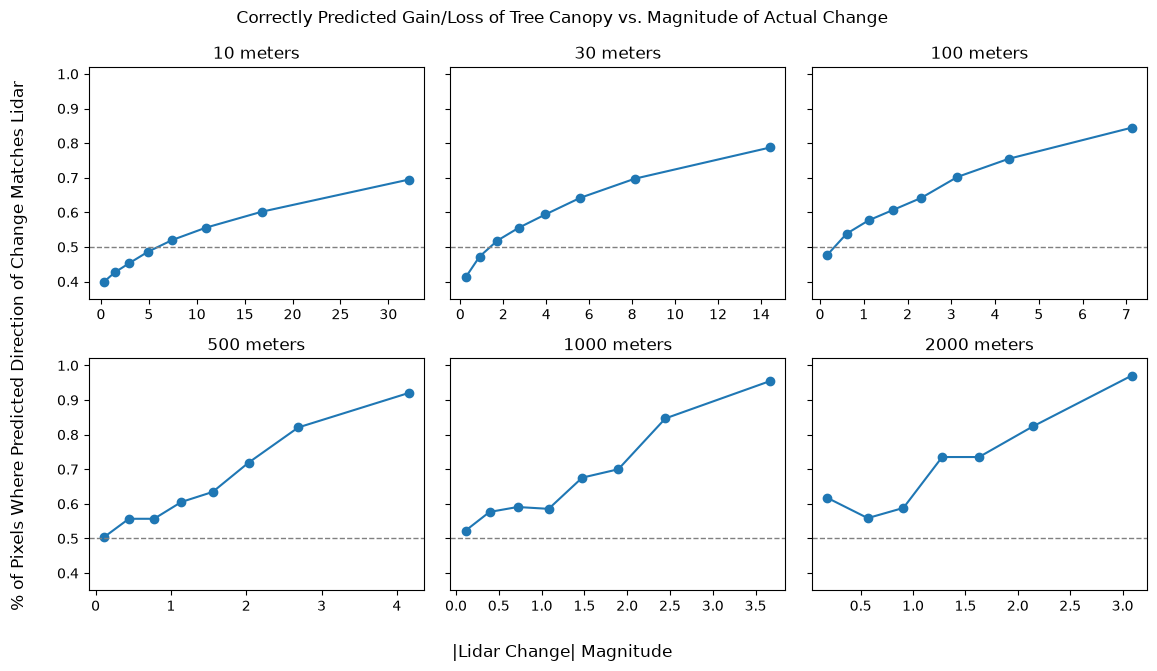

In [64]:
plot_sign_agreement_curves(sign_curve_results)

In [38]:
i = 10
change_type = 'diff'
save_dir = root / 'model_outputs' / 'resampled'
p_array = rioxarray.open_rasterio(save_dir/ f'{change_type}_preds_2018_2021_{i}m.tif').squeeze('band')
l_array = rioxarray.open_rasterio(save_dir/ f'{change_type}_lidar_2018_2021_{i}m.tif').squeeze('band')

p = p_array.values.ravel()
l = l_array.values.ravel() 
valid = np.isfinite(p) & np.isfinite(l)
pred, lidar = p[valid], l[valid]

pred.size

7769212

In [43]:
def binned_response_curve(scales,change_type,n_bins=12, min_bin=30):
    save_dir = root / 'model_outputs' / 'resampled'
    results_list = []
    for i in scales:
        p_array = rioxarray.open_rasterio(save_dir/ f'{change_type}_preds_2018_2021_{i}m.tif').squeeze('band')
        l_array = rioxarray.open_rasterio(save_dir/ f'{change_type}_lidar_2018_2021_{i}m.tif').squeeze('band')

        p = p_array.values.ravel()
        l = l_array.values.ravel() 
        valid = np.isfinite(p) & np.isfinite(l)
        pred, lidar = p[valid], l[valid]
     
        n_bins = int(min(n_bins, max(2, pred.size // min_bin))) # at least 2 bins
        edges = np.unique(np.quantile(lidar, np.linspace(0, 1, n_bins + 1)))
        if edges.size < 3:
            return {"note": "reference values too concentrated", "lidar_center": np.array([])}
        idx = np.clip(np.digitize(lidar, edges[1:-1]), 0, edges.size - 2)

        xc, p_med, p_lo, p_hi, bias, mae, count, rmse, pearson_r = [], [], [], [], [], [], [], [], []
        for b in range(edges.size - 1):
            sel = idx == b
            if sel.sum() < min_bin:
                continue
            p, l = pred[sel], lidar[sel]
            xc.append(float(np.median(l)))
            p_med.append(float(np.median(p)))
            lo, hi = np.percentile(p, [25, 75])
            p_lo.append(float(lo)); p_hi.append(float(hi))
            bias.append(float(np.mean(p - l)))
            mae.append(float(np.mean(np.abs(p - l))))
            count.append(int(sel.sum()))
            rmse.append(float(np.sqrt(np.mean((p - l) ** 2))))
            pearson_r.append(float(np.corrcoef(l, p)[0, 1]))
        results_list.append({"n":pred.size,"scale":i,"lidar_center": np.array(xc), "pred_median": np.array(p_med),
                "pred_p25": np.array(p_lo), "pred_p75": np.array(p_hi),
                "bias": np.array(bias), "mae": np.array(mae),
                "count": np.array(count), "rmse": np.array(rmse),"pearson_r":np.array(pearson_r)})
    return results_list

In [44]:
response_curves = binned_response_curve(change_type='diff',scales=[10,30,100,500,1000,2000])

In [53]:
def plot_change_response_curves(c):
    fig, axes = plt.subplots(2,3,figsize=(12, 7))
    axes = axes.ravel()

    for i,(ax,c) in enumerate(zip(axes,response_curves)):
        #lims = [0.0]
        line, = ax.plot(c["lidar_center"], c["pred_median"],marker='o',markersize=4)
        ax.fill_between(c["lidar_center"], c["pred_p25"], c["pred_p75"],
                        alpha=0.15)
        ax.axhline(0,linestyle='--',color='red',alpha=.08)
        ax.axvline(0,linestyle='--',color='red',alpha=.08)
        m = np.abs(c["lidar_center"]).max()
        ax.plot([-m, m], [-m, m], lw=1, color="grey")   # per-panel 1:1
        ax.set_title(f"{c['scale']} meters")

        

        label = (
                f"n = {c['n']:,}\n"
                f"r = {c['pearson_r'][i]:.2f}\n"
                f"bias = {c['bias'][i]:+.2f}"
            )

        ax.text(0.03, 0.97, label, transform=ax.transAxes,
                    va="top", ha="left", fontsize=10,
                    bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=1))
    
    # ax.set_xlabel("signed reference change (percent canopy, bin median)")
    fig.supylabel("Predicted Change (% Tree Canopy)")
    # ax.legend(title="scale")
    fig.suptitle("Predicted vs. Lidar Change in % Tree Canopy (2018-2021)")
    fig.supxlabel('Lidar Change (% Tree Canopy)')

    plt.tight_layout(rect=[0.0,0.0,1.0,0.98])
    plt.show()

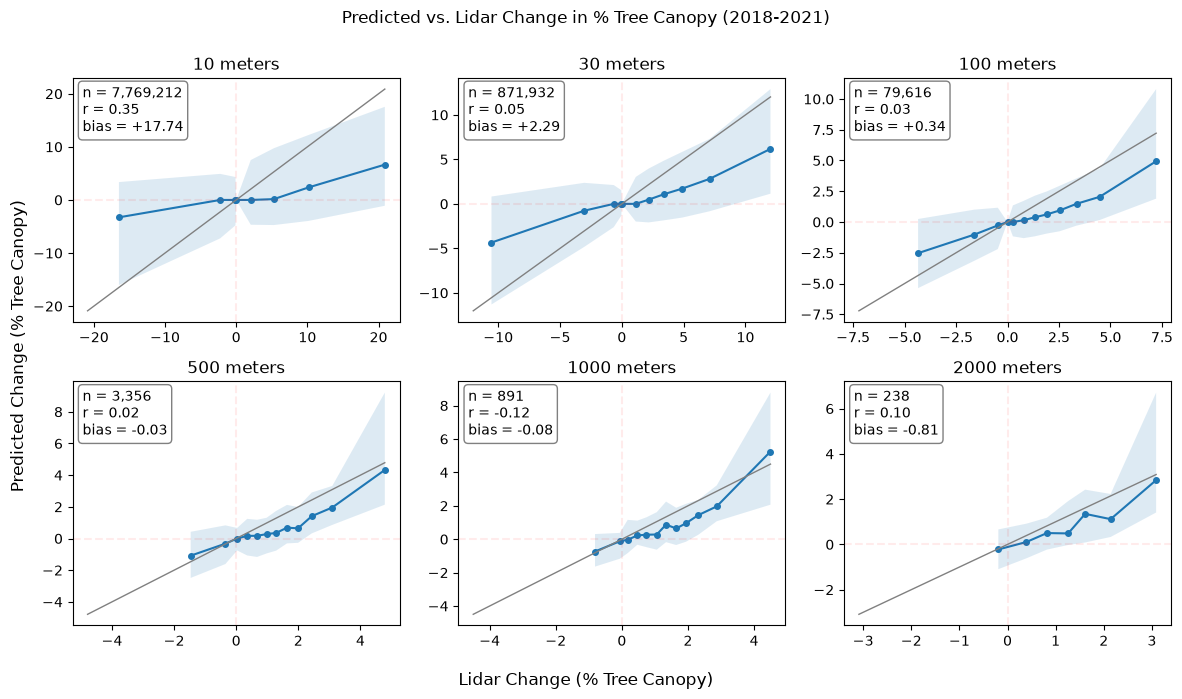

In [54]:
plot_change_response_curves(response_curves)

## "differencing two independently noisy estimates cancels the signal and roughly doubles the noise"

#### Correlation and Residual Analysis

In [79]:
def make_hexbin_plots(year):
    save_dir = root / 'model_outputs' / 'resampled'
    fig, axes = plt.subplots(2,3,figsize=(12,7),layout='constrained')
    axes=axes.ravel()
    for i,ax in zip([10,30,100,500,1000,2000],axes):
        p_array = rioxarray.open_rasterio(save_dir/ f'resamp_preds_{i}_{year}.tif').squeeze('band')
        if i ==10:
            l_array = rioxarray.open_rasterio(root / 'data' /f'nyc{year[-2:]}' / f'nyc{year[-2:]}_tree_canopy_lidar.tif').squeeze('band')
        else:
            l_array = rioxarray.open_rasterio(save_dir/ f'resamp_lidar_{i}_{year}.tif').squeeze('band')

        p = p_array.values.ravel()
        l = l_array.values.ravel() 
        valid = np.isfinite(p) & np.isfinite(l)
        pred, lidar = p[valid], l[valid]

        #slope, intercept = _rma_slope_intercept(lidar, pred)
        metrics =  {
                "n": int(pred.size),
                "pearson_r": float(np.corrcoef(lidar, pred)[0, 1]),   # tightness (partner to slope)
                "spearman_r": float(spearmanr(lidar, pred).correlation),  # robust/monotonic check
                #"ccc": float(_concordance_cc(lidar, pred)),           # one bounded agreement index
                #"nse": float(_nash_sutcliffe(lidar, pred)),
                #"rma_slope": float(slope),
                #"rma_intercept": float(intercept),
                "bias": float(np.mean(pred - lidar)),
                "mae": float(np.mean(np.abs(pred - lidar))),
                "rmse": float(np.sqrt(np.mean((pred - lidar) ** 2))),
            }
        label = (
        f"n = {metrics['n']:,}\n"
        f"r = {metrics['pearson_r']:.2f}\n"
        f"bias = {metrics['bias']:+.2f}\n"
        f"MAE = {metrics['mae']:.2f}\n"
        f"RMSE = {metrics['rmse']:.2f}"
    )

        gridsize=50
        if i < 100:
                idx = np.random.default_rng(42).choice(pred.size, 100000, replace=False)
                lidar, pred = (lidar[idx], pred[idx])
        #norm = mcolors.LogNorm(vmin=1,vmax=10000)
        #m = np.nanpercentile(np.abs(np.concatenate([lidar, pred])), 99)
        hb = ax.hexbin(lidar, pred,gridsize=gridsize, bins='log', extent=(0, 100, 0, 100), mincnt=1)
        ax.plot([0, 100], [0, 100], ls="--", lw=1, color="red")
        ax.text(0.03, 0.97, label, transform=ax.transAxes,
            va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=1))
        
        ax.set_title(f"{i} m")
    #fig.colorbar(hb,shrink=0.8,ax=axes)
    fig.supxlabel("Lidar % Tree Canopy")
    fig.supylabel("Predicted % Tree Canopy")
    fig.suptitle(f'Predicted vs. Lidar % Tree Canopy for {year} from 2021-trained Model')
    #fig.tight_layout()
    plt.show()


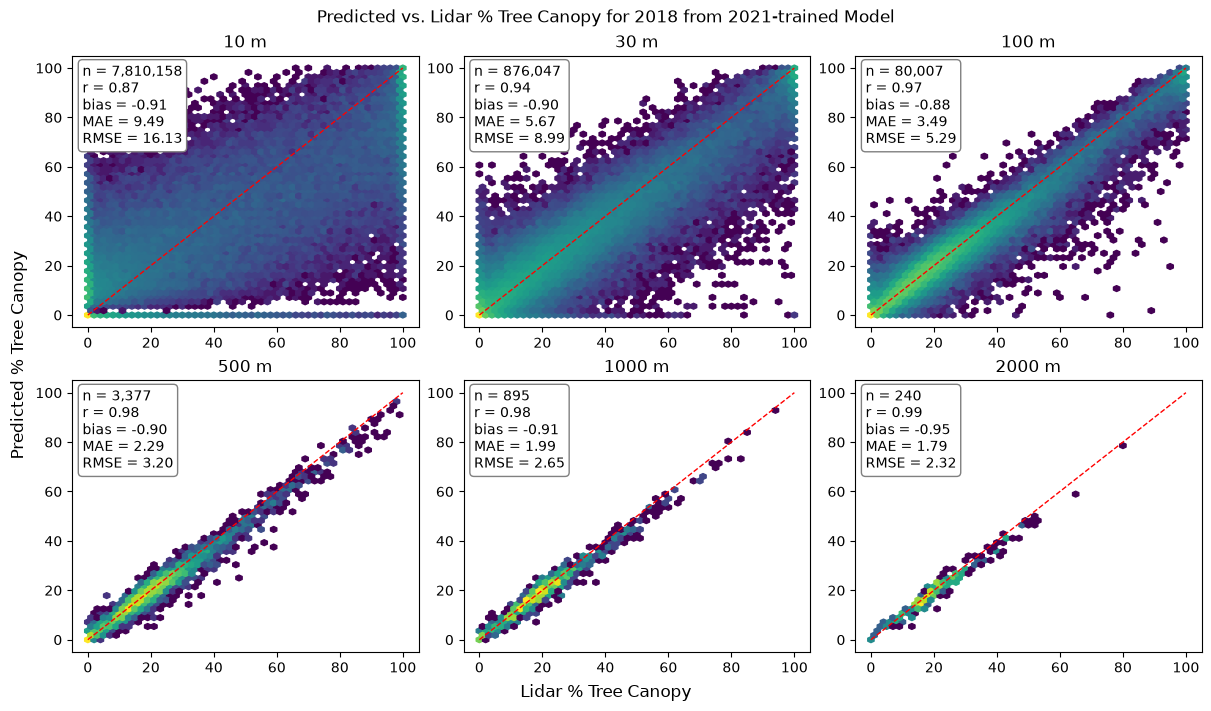

In [80]:
make_hexbin_plots(year='2018')

In [ ]:
### residuals plot

def make_residuals_hexbin_plots(year):
    save_dir = root / 'model_outputs' / 'resampled'
    fig, axes = plt.subplots(2,3,figsize=(12,7),layout='constrained')
    axes=axes.ravel()
    for i,ax in zip([10,30,100,500,1000,2000],axes):
        p_array = rioxarray.open_rasterio(save_dir/ f'resamp_preds_{i}_{year}.tif').squeeze('band')
        if i ==10:
            l_array = rioxarray.open_rasterio(root / 'data' /f'nyc{year[-2:]}' / f'nyc{year[-2:]}_tree_canopy_lidar.tif').squeeze('band')
        else:
            l_array = rioxarray.open_rasterio(save_dir/ f'resamp_lidar_{i}_{year}.tif').squeeze('band')

        p = p_array.values.ravel()
        l = l_array.values.ravel() 
        valid = np.isfinite(p) & np.isfinite(l)
        pred, lidar = p[valid], l[valid]

        resids = pred - lidar

        #slope, intercept = _rma_slope_intercept(lidar, pred)
        metrics =  {
                "n": int(pred.size),
                "pearson_r": float(np.corrcoef(lidar, pred)[0, 1]),   # tightness (partner to slope)
                "spearman_r": float(spearmanr(lidar, pred).correlation),  # robust/monotonic check
                #"ccc": float(_concordance_cc(lidar, pred)),           # one bounded agreement index
                #"nse": float(_nash_sutcliffe(lidar, pred)),
                #"rma_slope": float(slope),
                #"rma_intercept": float(intercept),
                "bias": float(np.mean(pred - lidar)),
                "mae": float(np.mean(np.abs(pred - lidar))),
                "rmse": float(np.sqrt(np.mean((pred - lidar) ** 2))),
            }
        label = (
        f"n = {metrics['n']:,}\n"
        f"r = {metrics['pearson_r']:.2f}\n"
        f"bias = {metrics['bias']:+.2f}\n"
        f"MAE = {metrics['mae']:.2f}\n"
        f"RMSE = {metrics['rmse']:.2f}"
    )

        gridsize=50
        if i < 100:
                idx = np.random.default_rng(42).choice(pred.size, 100000, replace=False)
                lidar, pred = (lidar[idx], pred[idx])
        #norm = mcolors.LogNorm(vmin=1,vmax=10000)
        #m = np.nanpercentile(np.abs(np.concatenate([lidar, pred])), 99)
        hb = ax.hexbin(lidar, pred,gridsize=gridsize, bins='log', extent=(0, 100, 0, 100), mincnt=1)
        ax.plot([0, 100], [0, 100], ls="--", lw=1, color="red")
        ax.text(0.03, 0.97, label, transform=ax.transAxes,
            va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=1))
        
        ax.set_title(f"{i} m")
    #fig.colorbar(hb,shrink=0.8,ax=axes)
    fig.supxlabel("Lidar % Tree Canopy")
    fig.supylabel("Predicted % Tree Canopy")
    fig.suptitle(f'Predicted vs. Lidar % Tree Canopy for {year} from 2021-trained Model')
    #fig.tight_layout()
    plt.show()


In [73]:
b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
a = b.union_all()

In [ ]:
def get_resids_per_bin(year,bins,bin_labels):

    save_dir = root / 'model_outputs' / 'resampled'
    b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
    a = gpd.GeoDataFrame({'name':'city'},index=[0],geometry=[b.union_all()],crs=26918)
   
    p_array = rioxarray.open_rasterio(save_dir/ f'resamp_preds_10_{year}.tif').squeeze('band')
    l_array = rioxarray.open_rasterio(root / 'data' /f'nyc{year[-2:]}' / f'nyc{year[-2:]}_tree_canopy_lidar.tif').squeeze('band')

    l_array = l_array.rio.clip(a.geometry) ## crop lidar to ensure same boundary (2021 raster has larger extent)
   
    p = p_array.values.ravel()
    l = l_array.values.ravel() 
    valid = np.isfinite(p) & np.isfinite(l)
    pred, lidar = p[valid], l[valid]

    resids = pred - lidar

    abs_resids = np.abs(resids)
    total_pixels = len(abs_resids)
    bin_ids_r = pd.cut(lidar, bins=bins, labels=bin_labels)

    lidar_all = l[np.isfinite(l)]
    bin_ids = pd.cut(lidar_all, bins=bins, labels=bin_labels)
    pct = bin_ids.value_counts().reindex(bin_labels) / len(lidar_all) * 100

    bin_stats = pd.DataFrame({
        'residual': resids,
        'abs_residual': abs_resids,
        'bin': bin_ids_r,
    }).groupby('bin',observed=False).agg(
        mean_bias=('residual', 'mean'),
        rmse=('residual', lambda x: np.sqrt(np.mean(x**2))),
        count=('residual', 'count')
    ).reset_index()

    #bin_stats['pct'] = (bin_stats['count']/total_pixels)*100
    bin_stats['pct'] = pct.values

    return bin_stats

def plot_residual_bins(years):

  
    bins = list(range(0, 101, 10))
    bin_labels = [f'{b}-{b+10}' for b in bins[:-1]]

    stats = {y:get_resids_per_bin(year=y,bins=bins,bin_labels=bin_labels) for y in years}
    

    x = np.arange(len(bin_labels))
    w = 0.4              

    color_dict = {'2018':'#2c7fb8','2021':'#a1d99b','2021_lidar':'#2A7C13','2018_lidar':'#76C457' }                      # bar width; two years -> 0.4 each

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for k, y in enumerate(years):
        off = (k - (len(years) - 1) / 2) * w   # centers the group on each tick
        axes[0].bar(x + off, stats[y]['mean_bias'], width=w, color=color_dict[y],label=f'{y} Predictions')
        axes[1].bar(x + off, stats[y]['pct'],       width=w, color=color_dict[f'{y}_lidar'],label=f'{y} Lidar')

  
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(bin_labels, rotation=45)
        ax.set_xlabel('Lidar % Tree Canopy')
        ax.legend(title='')

    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_ylabel('Mean Residual')
    axes[0].set_title('Mean Residual by Tree Canopy Percent')
    axes[1].set_ylabel('Percent of Total Pixels')
    axes[1].set_title('Citywide Distribution of Tree Canopy Percent')
    plt.tight_layout()
    plt.show()
    plt.show()

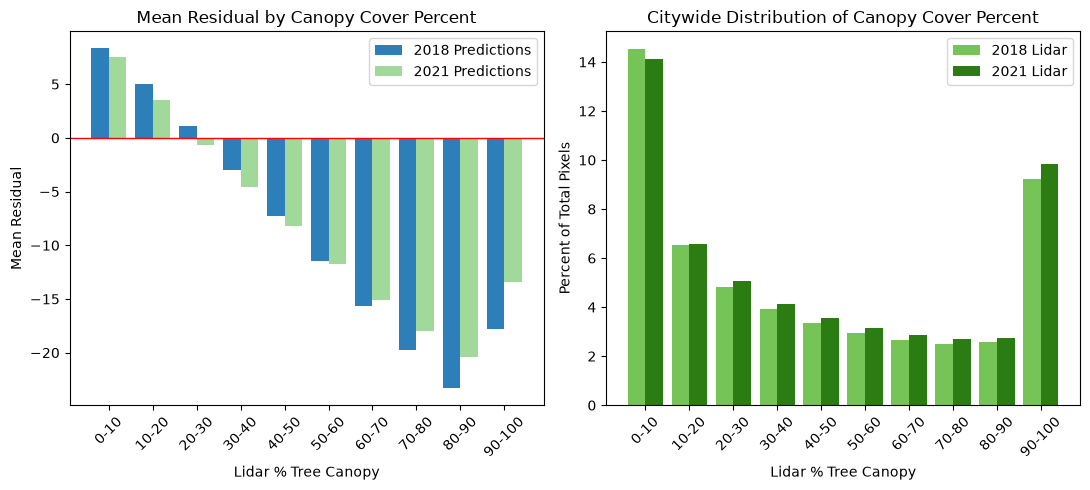

In [93]:
plot_residual_bins(years=['2018','2021'])

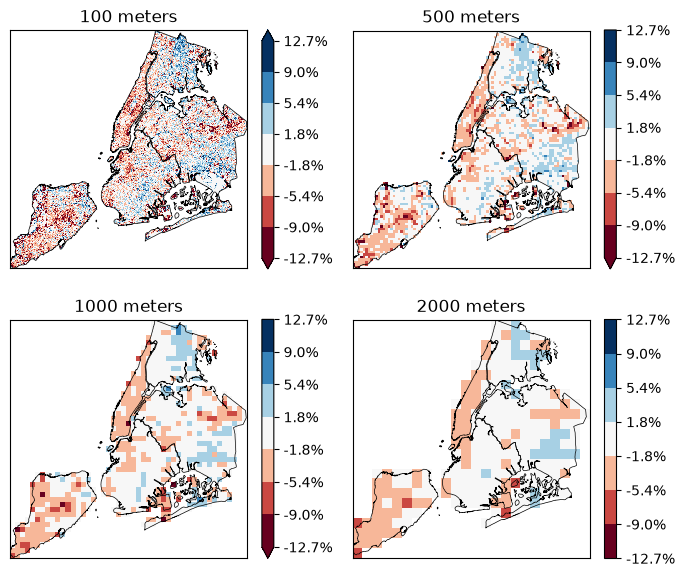

In [ ]:
b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
save_dir = root / 'model_outputs' / 'resampled'


def get_residuals_spatial(year,scales=[100,500,1000,2000]):
    res_list = []
    for i in scales:
    
        p_array = rioxarray.open_rasterio(save_dir/ f'resamp_preds_{i}_{year}.tif').squeeze('band')
        if i ==10:
            l_array = rioxarray.open_rasterio(root / 'data' /f'nyc{year[-2:]}' / f'nyc{year[-2:]}_tree_canopy_lidar.tif').squeeze('band')
        else:
            l_array = rioxarray.open_rasterio(save_dir/ f'resamp_lidar_{i}_{year}.tif').squeeze('band')

        d = p_array - l_array 

        res_list.append(d)

        if year == '2021':
            n_bands = 7
            res1 = np.concatenate([d.values[np.isfinite(d.values)] for d in res_list])
            V1 = np.nanpercentile(np.abs(res1), 98)
            bounds = np.linspace(-V1,V1,n_bands+1)

            return res_list, bounds

        else:
            return res_list

res_list_21, bounds = get_residuals_spatial('2021')
res_list_18 = get_residuals_spatial('2018')


def plot_residuals_spatial(res_list,bounds,scales=[100,500,1000,2000]):
    fig, axes = plt.subplots(2,2,figsize=(7,6))
    axes=axes.ravel()
    b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
    # discrete colorbar
    n_bands = 7
    cmap = plt.get_cmap('RdBu',n_bands)

    for i,(scale, ax) in enumerate(zip(scales,axes)):
      
        fmt = FuncFormatter(lambda x, _: f"{x:.1f}%")
            
        norm = BoundaryNorm(bounds,cmap.N)
        res_list[i].plot(ax=ax,cmap=cmap,norm=norm,cbar_kwargs={'shrink':0.9,'format':fmt})
        b.boundary.plot(ax=ax,color='black',linewidth=0.5)
        ax.set_aspect('equal')
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'{scale} meters')
    
        

    plt.tight_layout()
    plt.show()  

In [ ]:

def plot_coverage(scales=[500,2000],years=[2018,2021]):
    c_arrays = {}
    for year in years:
        for s in scales:
            c_arrays[f'c_{year}_{s}'] = rioxarray.open_rasterio(save_dir/ f'resamp_coverage_{s}_{year}_coverage.tif').squeeze('band')
    b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')

    fig, axes = plt.subplots(2,2,figsize=(7,6),layout='constrained')
    axes=axes.ravel()

    # discrete colorbar
    n_bands = 7
    #cmap = plt.get_cmap('RdBu',n_bands)
    l = []
    for scale in scales:
        for year in years:
            l.append((scale,year))

    for (scale,year), ax in zip(l,axes):
      
        
            
        #norm = BoundaryNorm(bounds,cmap.N)
        c = c_arrays[f'c_{year}_{scale}']
        im = c.plot(ax=ax,cmap='plasma',add_colorbar=False)
        b.boundary.plot(ax=ax,color='black',linewidth=0.5)
        ax.set_aspect('equal')
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'{year}')
        ax.text(0.03, 0.97, f'{scale} meters', transform=ax.transAxes,
                    va="top", ha="left", fontsize=10)

    fmt = FuncFormatter(lambda x, _: f"{x*100:.0f}%")
    cbar = fig.colorbar(im,ax=axes,shrink=0.70,format=fmt)
    cbar.ax.set_title('% Valid\n10m Pixels',fontsize=9)
   
    plt.show()  

In [24]:
### confusion with grass/shrub category

## look at pixels where model should predict <5% tree canopy and see if overpredicts when those pixels contain grass/shrub



def load_landcover_confusion(year, landcover,model_dir, data_dir):
    yy = year[-2:]
    
    p = rioxarray.open_rasterio(model_dir / f'nyc{yy}_from_nyc21_medians_only_model_canopy_percent.tif').squeeze('band').values.ravel()
   
    p_gs = rioxarray.open_rasterio(model_dir / f'nyc{yy}_from_nyc21_median_season_only_model_canopy_percent.tif').squeeze('band').values.ravel()
    lt = rioxarray.open_rasterio(data_dir / f'nyc{yy}' / f'nyc{yy}_tree_canopy_lidar.tif').squeeze('band').values.ravel()
    gr = rioxarray.open_rasterio(data_dir / f'nyc{yy}' / f'nyc{yy}_{landcover}_lidar.tif').squeeze('band').values.ravel()
    ok = np.isfinite(p) & np.isfinite(p_gs) & np.isfinite(lt) & np.isfinite(gr)
    
    return p[ok], p_gs[ok],lt[ok], gr[ok]

                     # predicted tree canopy minus true tree canopy




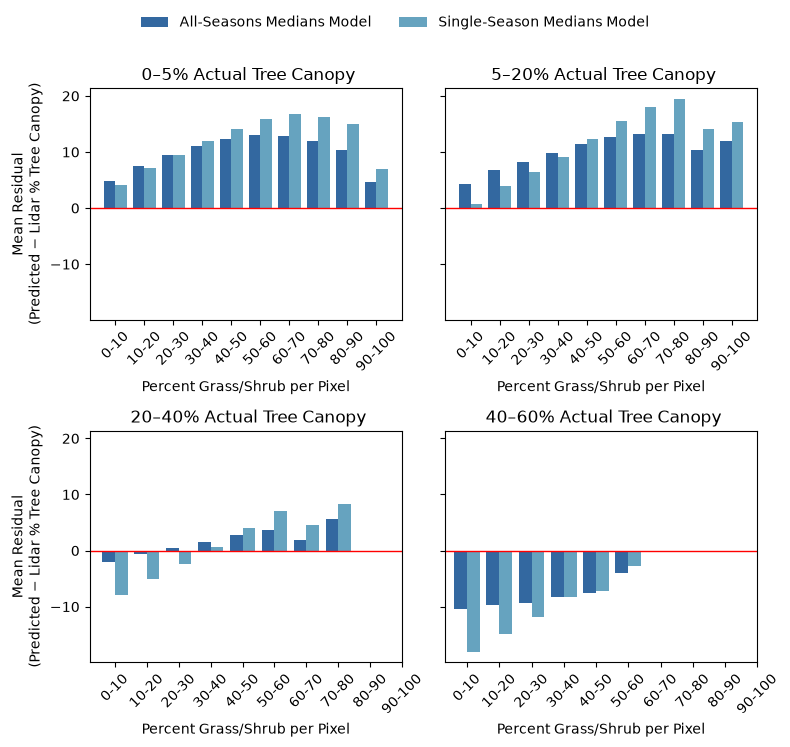

In [61]:
def plot_landcover_confusion(landcover):
    data_dir = root / 'data'
    model_dir = root / 'model_outputs'
    pred, pred_gs, tree, grass = load_landcover_confusion(year='2018', landcover=landcover,model_dir=model_dir, data_dir=data_dir)
    resid = pred - tree 
    resid_gs = pred_gs - tree

    bins = list(range(0, 101, 10)); labels = [f'{b}-{b+10}' for b in bins[:-1]]
    tree_bands = [(0, 5), (5, 20), (20, 40), (40, 60)]
    fig, axes = plt.subplots(2, 2, figsize=(8,7), sharey=True)
    axes=axes.ravel()
    x = np.arange(len(labels))
    # color_dict = {'grass_shrubs':'#7fbf7b','all_impervious':'gray'}
    # t = 'Grass/Shrub' if landcover == 'grass_shrubs' else 'All Impervious'
    w = 0.4
    for ax, (lo, hi) in zip(axes, tree_bands):
        m = (tree >= lo) & (tree < hi)
        s1 = pd.DataFrame({'r': resid[m], 'bin': pd.cut(grass[m], bins=bins, labels=labels)}) \
            .groupby('bin', observed=False)['r'].mean()
       
        s2 = pd.DataFrame({'r': resid_gs[m], 'bin': pd.cut(grass[m], bins=bins, labels=labels)}) \
           .groupby('bin', observed=False)['r'].mean()
        ax.bar(x - w/2, s1.values, width=w, color='#3368A0', label='All-Seasons Medians Model')
        ax.bar(x + w/2, s2.values, width=w, color='#66A3BF', label='Single-Season Medians Model')
        ax.axhline(0, color='red', lw=1)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
        ax.set_title(f' {lo}\u2013{hi}% Actual Tree Canopy'); ax.set_xlabel(f'Percent Grass/Shrub per Pixel')
    axes[0].set_ylabel('Mean Residual\n(Predicted \u2212 Lidar % Tree Canopy)')
    axes[2].set_ylabel('Mean Residual\n(Predicted \u2212 Lidar % Tree Canopy)')
    handles,lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles,lbls,loc='upper center', bbox_to_anchor=(0.5, 1.07), ncol=2, frameon=False)
    #fig.suptitle('Residual vs. grass fraction, holding true tree canopy fixed')
    plt.tight_layout(); plt.show()

plot_landcover_confusion(landcover='grass_shrubs')

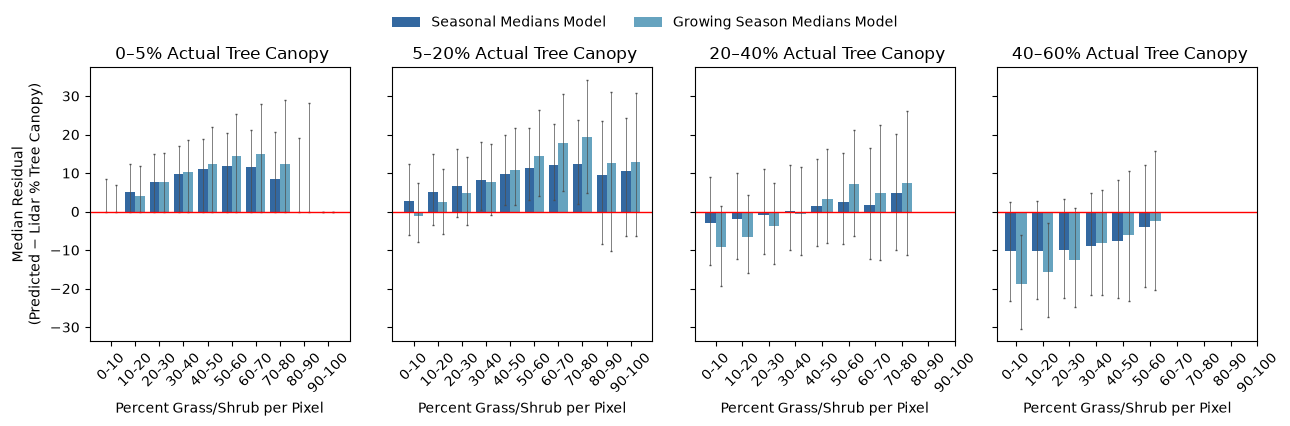

In [48]:
def median_iqr(resid, tree, cover, lo, hi, bins, labels):
    m = (tree >= lo) & (tree < hi)
    q = (pd.DataFrame({'r': resid[m], 'bin': pd.cut(cover[m], bins=bins, labels=labels)})
           .groupby('bin', observed=False)['r']
           .quantile([0.25, 0.5, 0.75]).unstack())
    med, q25, q75 = q[0.5].values, q[0.25].values, q[0.75].values
    yerr = np.vstack([med - q25, q75 - med])      # distance from median down to Q1, up to Q3
    return med, yerr


def plot_landcover_confusion(landcover):
    data_dir = root / 'data'
    model_dir = root / 'model_outputs'
    pred, pred_gs, tree, grass = load_landcover_confusion(year='2018', landcover=landcover,model_dir=model_dir, data_dir=data_dir)
    resid = pred - tree 
    resid_gs = pred_gs - tree

    bins = list(range(0, 101, 10)); labels = [f'{b}-{b+10}' for b in bins[:-1]]
    tree_bands = [(0, 5), (5, 20), (20, 40), (40, 60)]
    fig, axes = plt.subplots(1, len(tree_bands), figsize=(13, 4), sharey=True)
    x = np.arange(len(labels))
    # color_dict = {'grass_shrubs':'#7fbf7b','all_impervious':'gray'}
    # t = 'Grass/Shrub' if landcover == 'grass_shrubs' else 'All Impervious'
    w = 0.4
    for ax, (lo, hi) in zip(axes, tree_bands):
        med1, err1 = median_iqr(resid,tree, grass, lo, hi, bins, labels)
        med2, err2 = median_iqr(resid_gs,tree, grass, lo, hi, bins, labels)
        ax.bar(x - w/2, med1, width=w, color='#3368A0', label='Seasonal Medians Model')
        ax.errorbar(x - w/2, med1, yerr=err1, fmt='none', ecolor='0.3', elinewidth=0.5, capsize=1)
        ax.bar(x + w/2, med2, width=w, color='#66A3BF', label='Growing Season Medians Model')
        ax.errorbar(x + w/2, med2, yerr=err2, fmt='none', ecolor='0.3', elinewidth=0.5, capsize=1)
        ax.axhline(0, color='red', lw=1)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
        ax.set_title(f' {lo}\u2013{hi}% Actual Tree Canopy'); ax.set_xlabel(f'Percent Grass/Shrub per Pixel')
    axes[0].set_ylabel('Median Residual\n(Predicted \u2212 Lidar % Tree Canopy)')
    handles,lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles,lbls,loc='upper center', bbox_to_anchor=(0.5, 1.07), ncol=2, frameon=False)
    #fig.suptitle('Residual vs. grass fraction, holding true tree canopy fixed')
    plt.tight_layout(); plt.show()

plot_landcover_confusion(landcover='grass_shrubs')

#### Shrub/tree confusion

In [ ]:
### read-do grass/shrub residual plot as heat map
## y-axis pct grass/shrub, x-axis pct tree canopy, diverging color for residuals
# expect to see high residuals at 0-20% tree canopy and higher levels of grass/shrub
# declining residuals with increasing tree canopy pct 

In [ ]:
## resample chm to 90th percentile per 10m pixel
# this gives the tallest shrubs/trees present so grass does not dominate a grass/shrub pixel
## but if there is one tree and lots of shrubs, pixel will have height of taller shrubs, not the single tree
## limit plot to less than certain height?

## resample to fraction of 10m pixel below 2m height
# shows if grass/low vegetation is getting confused for trees

### mask buildings/impervious; retain only 0% impervious cells so we know we are only looking at vegetation

### or mask using grass/shruabs layer; retain only 100% grass/shrub so we know that no trees are present
## does overprediction correlate with height of shrubs
## geared towards question: does model mistake tall shrubs for tree canopy

## plot height vs tree pct with residual as diverging cover

#### Plot Acquisition Dates

In [4]:
t18 = xr.open_zarr(root / 'data' / 'nyc18' / 'nyc18_daily_raw_aligned.zarr')
dates_2018_new = t18.time.values

t21 = xr.open_zarr(root / 'data' / 'nyc21' / 'nyc21_daily_raw_aligned.zarr')
dates_2021_new = t21.time.values

In [17]:
t21.chunksizes

Frozen({'time': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'band': (2, 2, 2, 2, 2), 'y': (586, 586, 586, 586, 586, 586, 586, 585), 'x': (584, 584, 584, 584, 584, 584, 584, 583)})

In [14]:
t18_old = xr.open_zarr(r'D:\original_data_for_paper\nyc18\nyc18_daily_raw_10m_aligned.zarr')
dates_2018_old = t18_old.time.values

t21_old = xr.open_zarr(r'D:\original_data_for_paper\nyc21\nyc21_daily_raw_10m_aligned.zarr')
dates_2021_old = t21_old.time.values

In [6]:
all_dates = pd.read_csv(root / 'data' / 'all_sentinel_dates_2017_2018_2021.csv')

all_dates['datetime'] = pd.to_datetime(all_dates['datetime'])

# drop tile TXK bc it doesn't contribute to coverage
all_dates = all_dates.loc[all_dates['tile']!='18TXK']
## dates with tiles TWK, TWL and TXL have complete coverage
# count how many tiles per date - 3 is full coverage

coverage = all_dates.groupby('datetime')['tile'].count().reset_index()
coverage['year'] = coverage['datetime'].dt.year

In [7]:
dates_2017 = coverage.loc[coverage['year']==2017]
dates_2018 = coverage.loc[coverage['year']==2018]
dates_2021 = coverage.loc[coverage['year']==2021]

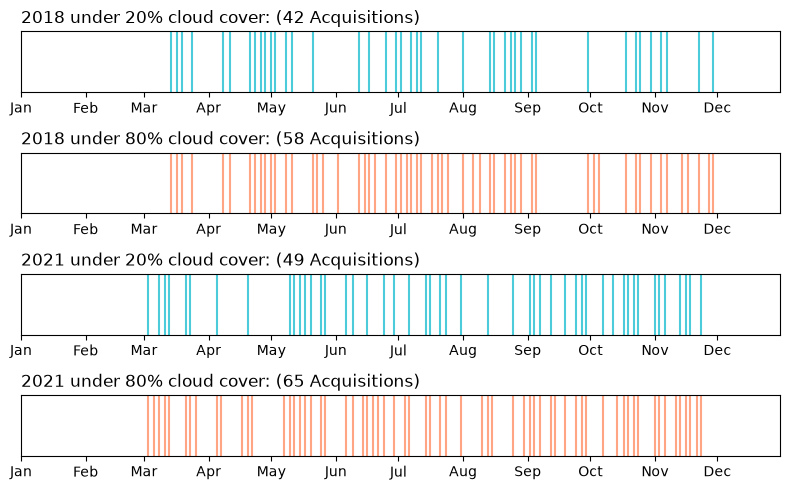

In [15]:
# Extract acquisition dates from both datasets
from matplotlib.lines import Line2D

fig, axes = plt.subplots(4, 1, figsize=(8, 5), sharex=False)

for ax, dates, year,cc in zip(
    axes, 
    [dates_2018_old,dates_2018_new,dates_2021_old,dates_2021_new], 
    [2018,2018,2021,2021],
    [20,80,20,80]
):
    for date in dates:
            color = '#00B7CD' if cc==20 else '#FF7F50'
            ax.axvline(date, color=color, alpha=0.7, linewidth=1.5)
    
    ax.set_xlim(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'))
    ax.set_yticks([])
    
    # Add month labels
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
    
    # # Shade spring period
    # spring_start = pd.Timestamp(f'{year}-03-01')
    # spring_end = pd.Timestamp(f'{year}-06-01')
    # ax.axvspan(spring_start, spring_end, alpha=0.1, color='green')
    ax.set_title(f'{year} under {cc}% cloud cover: ({len(dates)} Acquisitions)',loc='left')

    # if year == 2017:
    #     custom_handles = [
    #     Line2D([0], [0], color='#FF7F50', lw=2,  label='Full Coverage'),
    #     Line2D([0], [0], color='#00B7CD', lw=2, label='Partial Coverage')
    # ]
    #     labels = [h.get_label() for h in custom_handles]
        
        #ax.legend(handles=custom_handles,labels=labels,loc='upper left')


#fig.legend(custom_handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
          # ncol=2, frameon=False)

#plt.suptitle('Sentinel-2 Acquisition Dates by Year', fontsize=12)
plt.tight_layout()
#plt.savefig('acquisition_dates.png', dpi=150)
plt.show()


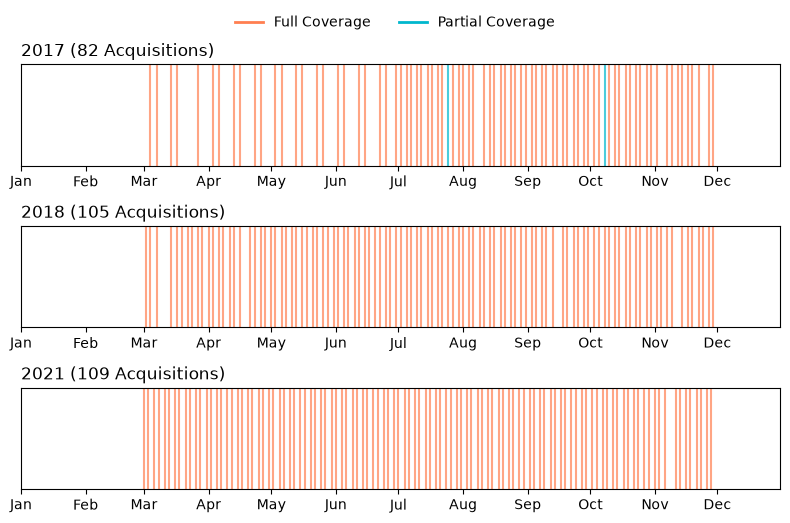

In [4]:
# Extract acquisition dates from both datasets
from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=False)

for ax, dates, year in zip(
    axes, 
    [dates_2017, dates_2018,dates_2021], 
    [2017, 2018,2021]
):
    # Plot vertical lines for each acquisition
    for date,tile in zip(dates['datetime'],dates['tile']):
        color = '#FF7F50' if tile>1 else '#00B7CD'
        ax.axvline(date, color=color, alpha=0.7, linewidth=1.5)
    
    ax.set_xlim(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'))
    ax.set_yticks([])
    
    # Add month labels
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
    
    # # Shade spring period
    # spring_start = pd.Timestamp(f'{year}-03-01')
    # spring_end = pd.Timestamp(f'{year}-06-01')
    # ax.axvspan(spring_start, spring_end, alpha=0.1, color='green')
    ax.set_title(f'{year} ({len(dates)} Acquisitions)',loc='left')

    if year == 2017:
        custom_handles = [
        Line2D([0], [0], color='#FF7F50', lw=2,  label='Full Coverage'),
        Line2D([0], [0], color='#00B7CD', lw=2, label='Partial Coverage')
    ]
        labels = [h.get_label() for h in custom_handles]
        
        #ax.legend(handles=custom_handles,labels=labels,loc='upper left')


fig.legend(custom_handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=2, frameon=False)

#plt.suptitle('Sentinel-2 Acquisition Dates by Year', fontsize=12)
plt.tight_layout()
#plt.savefig('acquisition_dates.png', dpi=150)
plt.show()


In [ ]:
nlcd_array = rioxarray.open_rasterio(root / 'data' / 'nlcd' / f'nlcd_2018.tif')



CRS.from_wkt('PROJCS["Albers_Conical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [92]:
### nlcd comparison

def get_resids_per_bin(year,bins,bin_labels):

    save_dir = root / 'model_outputs' / 'resampled'
    b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
    a = gpd.GeoDataFrame({'name':'city'},index=[0],geometry=[b.union_all()],crs=26918)

    nlcd_array = rioxarray.open_rasterio(root / 'data' / 'nlcd' / f'nlcd_{year}.tif')
    p_array = rioxarray.open_rasterio(save_dir/ f'resamp_preds_30_{year}.tif').squeeze('band')
    l_array = rioxarray.open_rasterio(save_dir /f'resamp_lidar_30_{year}.tif').squeeze('band')

    nlcd_array = nlcd_array.rio.reproject_match(p_array)

    l_array = l_array.rio.clip(a.geometry) ## crop lidar to ensure same boundary (2021 raster has larger extent)
    nlcd_array = nlcd_array.rio.clip(a.geometry) 
    
    p = p_array.values.ravel()
    l = l_array.values.ravel() 
    n = nlcd_array.values.ravel()
    valid = np.isfinite(p) & np.isfinite(l) & np.isfinite(n)
    pred, lidar, nlcd = p[valid], l[valid], n[valid]

    resids = pred - lidar
    resids_nlcd = nlcd - lidar

    abs_resids = np.abs(resids)
    bin_ids_r = pd.cut(lidar, bins=bins, labels=bin_labels)

    bin_stats = pd.DataFrame({
        'residual': resids,
        'abs_residual': abs_resids,
        'nlcd_residual':resids_nlcd,
        'bin': bin_ids_r,
    }).groupby('bin',observed=False).agg(
        mean=('residual', 'mean'),
        mean_nlcd=('nlcd_residual','mean'),
        rmse=('residual', lambda x: np.sqrt(np.mean(x**2))),
        rmse_nlcd=('nlcd_residual', lambda x: np.sqrt(np.mean(x**2)))
    ).reset_index()


    return bin_stats

def plot_residual_bins(years):

  
    bins = list(range(0, 101, 10))
    bin_labels = [f'{b}-{b+10}' for b in bins[:-1]]

    stats = {y:get_resids_per_bin(year=y,bins=bins,bin_labels=bin_labels) for y in years}
    

    x = np.arange(len(bin_labels))
    w = 0.4              

    color_dict = {'pred':'#a1d99b','nlcd':'gray'}                      # bar width; two years -> 0.4 each

    fig, axes = plt.subplots(1,2,figsize=(11, 5),sharey=True)
    for ax, y in zip(axes,years):
        s = stats[y]
        ax.bar(x - w/2, s['mean'],      w, color=color_dict['pred'], label='Model (30 m)')
        ax.bar(x + w/2, s['mean_nlcd'], w, color=color_dict['nlcd'], label='NLCD')
        ax.axhline(0, color='red', lw=1)
        ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=45)
        ax.set_title(str(y))
        ax.set_xlabel('Lidar % Tree Canopy')
        ax.legend(frameon=False)

    axes[0].set_ylabel('Mean Residual')
    plt.tight_layout()
    plt.show()

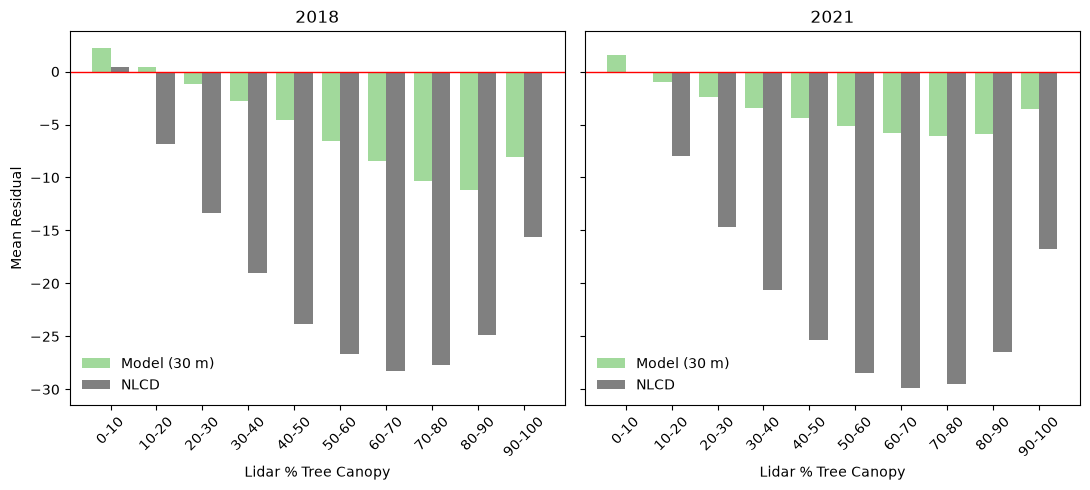

In [93]:
plot_residual_bins(['2018','2021'])

In [40]:
### extract points and plot time series
from exactextract import exact_extract 
import geopandas as gpd
import pandas as pd
import xarray
import rioxarray
from pathlib import Path
root = Path.cwd()

years = [18,19,20,21]
pred_arrays = [rioxarray.open_rasterio(root / 'model_outputs' / f'nyc{y}_from_nyc21_medians_only_model_canopy_percent.tif') for y in years]

test_points = gpd.read_file(root / 'data' / 'test_points.gpkg')
test_points['buffer'] = test_points.buffer(5)
test_points = test_points.set_geometry('buffer').drop(columns='geometry').rename_geometry('geometry')
test_points['id'] = range(len(test_points))

df = []
for a,year in zip(pred_arrays,years):
    d = exact_extract(a,test_points,['mode'],include_cols=['id','type','location'],output='pandas')
    d['year'] = f'20{year}'
    df.append(d)

out_df = pd.concat(df)

In [41]:
out_df['year'] = pd.to_datetime(out_df['year'])

In [42]:
out_df

,id,type,location,mode,year
0,0,forest,inwood,98.160965,2018-01-01
1,1,forest,centralpark,94.738976,2018-01-01
2,2,lawn,centralpark,0.000000,2018-01-01
3,3,lawn,centralpark,0.000000,2018-01-01
4,4,streettree,manhattan,52.087711,2018-01-01
...,...,...,...,...,...
11,11,shrubs,jamaicabay,49.156448,2021-01-01
12,12,shrubs,statenisland,0.000000,2021-01-01
13,13,shrubs,statenisland,0.000000,2021-01-01
14,14,streettree,statenisland,96.074409,2021-01-01


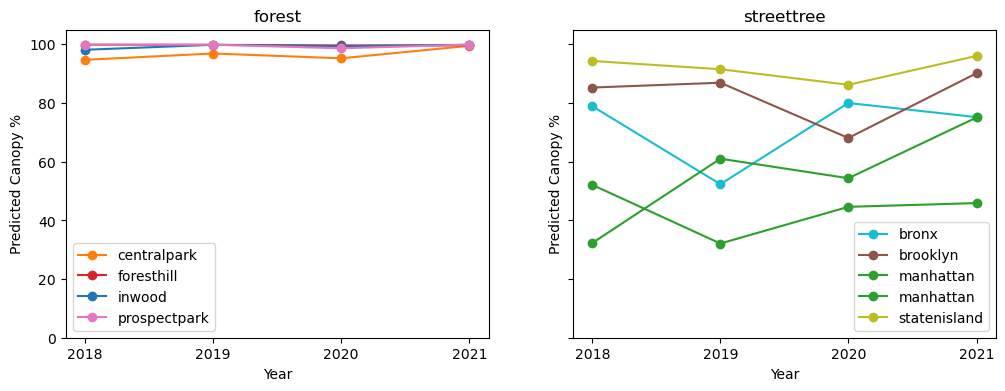

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


fig, axes = plt.subplots(1, 2,figsize=(12, 4), sharey=True)

color_dict = {k:l for l,k in zip(plt.color_sequences['tab10'],out_df['location'].unique())}

for t, ax in zip(['forest', 'streettree'], axes):
    sub = out_df[out_df['type'] == t]
    for (loc, tid), q in sub.groupby(['location', 'id']):
        q = q.sort_values('year')
      
        ax.plot(q['year'], q['mode'], marker='o', color=color_dict[loc],label=loc)
    ax.set_title(t)
    ax.set_xlabel('Year'); ax.set_ylabel('Predicted Canopy %')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylim(0,105)
    ax.legend()
    

In [ ]:
## net change/gross gain/loss


## plot residuals at different scales against % canopy cover. 

## change through time:

## diff of different resolutions

## fit linear regression

## for each method, assess percentage of predictions that are in the correct direction (gain or loss) at each scale. 

## what land cover types are predicted incorrectly? plot change resids against % canopy cover. 

## choose a few pixels to plot time series. maybe a few from dense forest and a few from street trees. also wetland trees that could be confused with shrubs.

## plot aquisition density for all four years. do fewer acquisitions mean less reliable predictions? or coverage that differs from training year?

## partial dependence plots for top variables vs tree canopy for 2018 and 2021. 